# Tuzatilgan natijalar — tekshiruv daftari

`appliedmath-lexflow` loyihasining **Natijalar bloki** tuzatilgandan keyingi holati.
Ushbu daftar temporal benchmarkning solverdan mustaqil (invariant) natijalarini,
price-of-fairness va leximin qo'shimchalarini interaktiv ko'rsatadi.

Ikki tuzatilgan nuqson:
1. **ε-oqishi** — Stage 3 endi Stage-2 optimumini *aniq* saqlaydi (Ω₃ = 0.40, oldin 0.39999998).
2. **Ω invariantligi** — 0.75 bitta cho'qqining qiymati edi; Stage-2 optimal yuzida Ω ∈ [2/5, 21/20].

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
from appliedmath_lexflow.io import load_benchmark
from appliedmath_lexflow.lexicographic import solve_three_stage
from appliedmath_lexflow.robust import stage2_variation_bounds, price_of_fairness, solve_leximin
DATA = ROOT / "Data" / "benchmarks"
NAMES = ["branching_shared_edge_bottleneck","chain_source_bottleneck",
         "star_edge_bottleneck","temporal_lexicographic","tie_bottleneck"]
models = {n: load_benchmark(DATA / f"{n}.json") for n in NAMES}

## 1. Temporal benchmark — maqola vs tuzatilgan kod

In [2]:
t = models["temporal_lexicographic"]
sol = solve_three_stage(t); b = stage2_variation_bounds(t); lex = solve_leximin(t)
print("lambda*                :", 0.6)
print("theta* (Stage 2)       :", round(sol.stage2.weighted_satisfaction,6))
print("Stage-3 satisfaction   :", round(sol.stage3.weighted_satisfaction,6), "(= theta* aniq)")
print("Omega(r2) solver vertex:", sol.stage2.temporal_variation, "(maqola shu 0.75 ni 'natija' degan)")
print("Omega range (INVARIANT):", f"[{b.omega_min_exact}, {b.omega_max_exact}] = [{b.omega_min:.3f}, {b.omega_max:.3f}]")
print("Stage-3 Omega*         :", round(sol.stage3.temporal_variation,4))
print("Invariant reduction    :", f"{b.reduction_fraction*100:.1f}%  (maqola: 46.7% - takrorlanmas)")
print("Leximin (yagona)       :", f"Omega={lex.temporal_variation:.3f}, satisfaction={lex.weighted_satisfaction:.6f}, levels={lex.levels}")

lambda*                : 0.6
theta* (Stage 2)       : 0.733333
Stage-3 satisfaction   : 0.733333 (= theta* aniq)
Omega(r2) solver vertex: 0.75 (maqola shu 0.75 ni 'natija' degan)
Omega range (INVARIANT): [2/5, 21/20] = [0.400, 1.050]
Stage-3 Omega*         : 0.4
Invariant reduction    : 61.9%  (maqola: 46.7% - takrorlanmas)
Leximin (yagona)       : Omega=0.400, satisfaction=0.733333, levels=(0.6, 0.8)


## 2. Ω bitta son emas — [0.40, 1.05] oralig'i
Qizil romb — HiGHS qaytargan cho'qqi (0.75). Boshqa solver oraliqdagi istalgan qiymatni berishi mumkin.

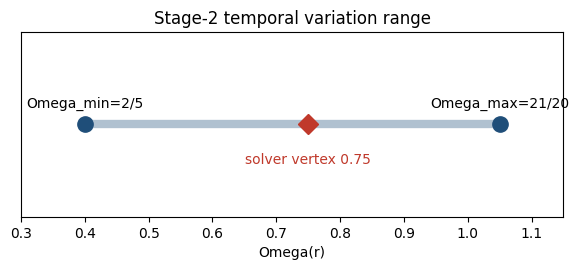

In [3]:
fig, ax = plt.subplots(figsize=(7,2.4))
ax.hlines(0,b.omega_min,b.omega_max,color="#1F4E79",lw=6,alpha=.35)
ax.plot([b.omega_min,b.omega_max],[0,0],"o",color="#1F4E79",ms=11)
ax.plot(sol.stage2.temporal_variation,0,"D",color="#C0392B",ms=10,zorder=5)
ax.annotate("Omega_min=2/5",(b.omega_min,0),xytext=(0,12),textcoords="offset points",ha="center")
ax.annotate("Omega_max=21/20",(b.omega_max,0),xytext=(0,12),textcoords="offset points",ha="center")
ax.annotate("solver vertex 0.75",(0.75,0),xytext=(0,-28),textcoords="offset points",ha="center",color="#C0392B")
ax.set_xlim(0.3,1.15); ax.set_yticks([]); ax.set_xlabel("Omega(r)")
ax.set_title("Stage-2 temporal variation range"); plt.show()

## 3. Price of fairness (5 benchmark)

branching_shared_edge_bottleneck   Z_eff=  75.050 Z_fair=  74.153 PoF= 1.20%
chain_source_bottleneck            Z_eff=  72.000 Z_fair=  72.000 PoF= 0.00%
star_edge_bottleneck               Z_eff= 110.000 Z_fair= 110.000 PoF= 0.00%
temporal_lexicographic             Z_eff=  22.000 Z_fair=  22.000 PoF= 0.00%
tie_bottleneck                     Z_eff=  75.000 Z_fair=  75.000 PoF= 0.00%


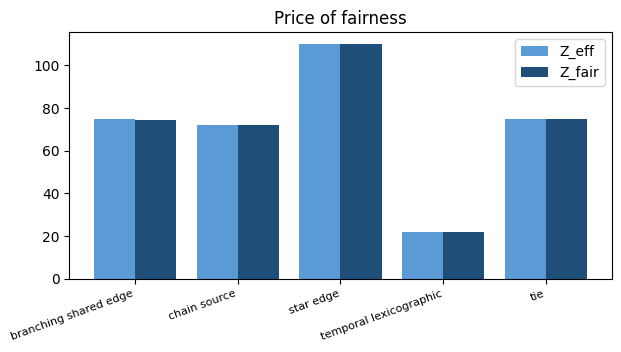

In [4]:
pof = {n: price_of_fairness(m) for n,m in models.items()}
for n in NAMES:
    p=pof[n]; print(f"{n:34s} Z_eff={p.efficiency_optimum:8.3f} Z_fair={p.fair_delivery:8.3f} PoF={p.price_of_fairness*100:5.2f}%")
fig,ax=plt.subplots(figsize=(7,3.2)); x=range(len(NAMES))
ax.bar([i-.2 for i in x],[pof[n].efficiency_optimum for n in NAMES],.4,label="Z_eff",color="#5B9BD5")
ax.bar([i+.2 for i in x],[pof[n].fair_delivery for n in NAMES],.4,label="Z_fair",color="#1F4E79")
ax.set_xticks(list(x)); ax.set_xticklabels([n.replace('_bottleneck','').replace('_',' ') for n in NAMES],rotation=20,ha="right",fontsize=8)
ax.legend(); ax.set_title("Price of fairness"); plt.show()

## 4. Leximin — yagona silliq taqsimot

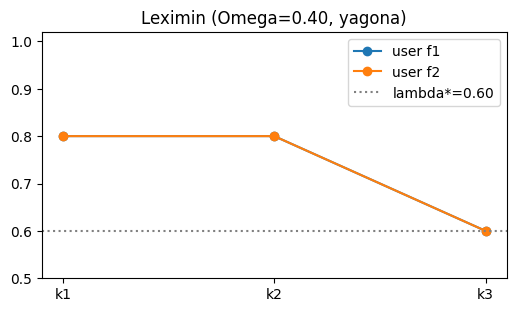

In [5]:
fig,ax=plt.subplots(figsize=(6,3.2)); P=list(t.periods)
for u in t.user_ids: ax.plot(P,[lex.ratios[(k,u)] for k in P],"-o",label=f"user {u}")
ax.axhline(lex.minimum_ratio,ls=":",color="gray",label=f"lambda*={lex.minimum_ratio:.2f}")
ax.set_ylim(0.5,1.02); ax.set_title("Leximin (Omega=0.40, yagona)"); ax.legend(); plt.show()